# Portfolio Risk Analytics & Stress Testing Engine — with a Solvency II-Style Insurance Risk Perspective

### Project Objective

The objective of this project is to build a Python-based quantitative risk
analytics framework using real public financial market data.

The analysis focuses on data quality, market returns, volatility,
correlation, portfolio risk and downside risk measures, and is later
extended to Value at Risk (VaR), Expected Shortfall (ES), stress testing,
and factor-based analysis.


## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import scipy.stats as stats
import statsmodels.api as sm
print("All libraries imported successfully.")

All libraries imported successfully.


## Market Data Acquisition and Initial Inspection

The analysis uses publicly available market data for two liquid exchange-traded
funds that serve as market proxies for different parts of an institutional
investment portfolio.

EUNL.DE is used as a global equity proxy, while EUN5.DE is used as a euro
investment-grade corporate bond proxy.

The downloaded data is inspected before any calculations are performed to
ensure that its structure and quality are suitable for further analysis.

In [2]:
tickers = [
    "EUNL.DE",
    "EUN5.DE"
]

prices = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-09-01",
    auto_adjust=True
)


[*********************100%***********************]  2 of 2 completed


In [3]:
prices.head()

Price            Close                   High                    Low  \
Ticker         EUN5.DE    EUNL.DE     EUN5.DE    EUNL.DE     EUN5.DE   
Date                                                                   
2020-01-02  115.495918  56.700001  115.654871  56.933998  115.238151   
2020-01-03  115.702141  56.680000  115.818130  56.782001  115.672065   
2020-01-06  115.702141  56.549999  115.873982  56.576000  115.650590   
2020-01-07  115.633385  56.902000  115.736487  56.964001  115.590421   
2020-01-08  115.517410  57.136002  115.689251  57.223999  115.431483   

Price                        Open             Volume          
Ticker        EUNL.DE     EUN5.DE    EUNL.DE EUN5.DE EUNL.DE  
Date                                                          
2020-01-02  56.562000  115.315490  56.599998   31270  431170  
2020-01-03  56.340000  115.818130  56.585999   32368  289881  
2020-01-06  56.085999  115.873982  56.462002   35570  228778  
2020-01-07  56.669998  115.590421  56.810001   24186  274864  
2020-01-08  56.630001  115.689251  56.698002    6653  246622

In [4]:
print("Shape:", prices.shape)
print("\nColumns:")
print(prices.columns)
print("\nData types:")
print(prices.dtypes)

Shape: (1695, 10)

Columns:
MultiIndex([( 'Close', 'EUN5.DE'),
            ( 'Close', 'EUNL.DE'),
            (  'High', 'EUN5.DE'),
            (  'High', 'EUNL.DE'),
            (   'Low', 'EUN5.DE'),
            (   'Low', 'EUNL.DE'),
            (  'Open', 'EUN5.DE'),
            (  'Open', 'EUNL.DE'),
            ('Volume', 'EUN5.DE'),
            ('Volume', 'EUNL.DE')],
           names=['Price', 'Ticker'])

Data types:
Price   Ticker 
Close   EUN5.DE    float64
        EUNL.DE    float64
High    EUN5.DE    float64
        EUNL.DE    float64
Low     EUN5.DE    float64
        EUNL.DE    float64
Open    EUN5.DE    float64
        EUNL.DE    float64
Volume  EUN5.DE      int64
        EUNL.DE      int64
dtype: object


In [5]:
print("Missing values:")
print(prices.isna().sum())

print("\nDuplicate dates:")
print(prices.index.duplicated().sum())

Missing values:
Price   Ticker 
Close   EUN5.DE    0
        EUNL.DE    0
High    EUN5.DE    0
        EUNL.DE    0
Low     EUN5.DE    0
        EUNL.DE    0
Open    EUN5.DE    0
        EUNL.DE    0
Volume  EUN5.DE    0
        EUNL.DE    0
dtype: int64

Duplicate dates:
0


In [6]:
close_prices = prices["Close"].copy()

close_prices.head()

Ticker,EUN5.DE,EUNL.DE
Date,,
2020-01-02,115.495918,56.700001
2020-01-03,115.702141,56.680000
2020-01-06,115.702141,56.549999
2020-01-07,115.633385,56.902000
2020-01-08,115.517410,57.136002


In [7]:
close_prices.isna().sum()

Ticker
EUN5.DE    0
EUNL.DE    0
dtype: int64

In [8]:
close_prices[close_prices.isna().any(axis=1)]

Ticker,EUN5.DE,EUNL.DE
Date,,


In [9]:
close_prices = close_prices.dropna()

In [10]:
close_prices.isna().sum()

Ticker
EUN5.DE    0
EUNL.DE    0
dtype: int64

In [11]:
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

print("Data period:")
print(prices.index.min(), "to", prices.index.max())

Data period:
2020-01-02 00:00:00 to 2026-08-31 00:00:00


## Historical Price Development

Before calculating returns, the historical price series are visualized to
obtain an initial view of how the selected market proxies evolved over the
sample period.

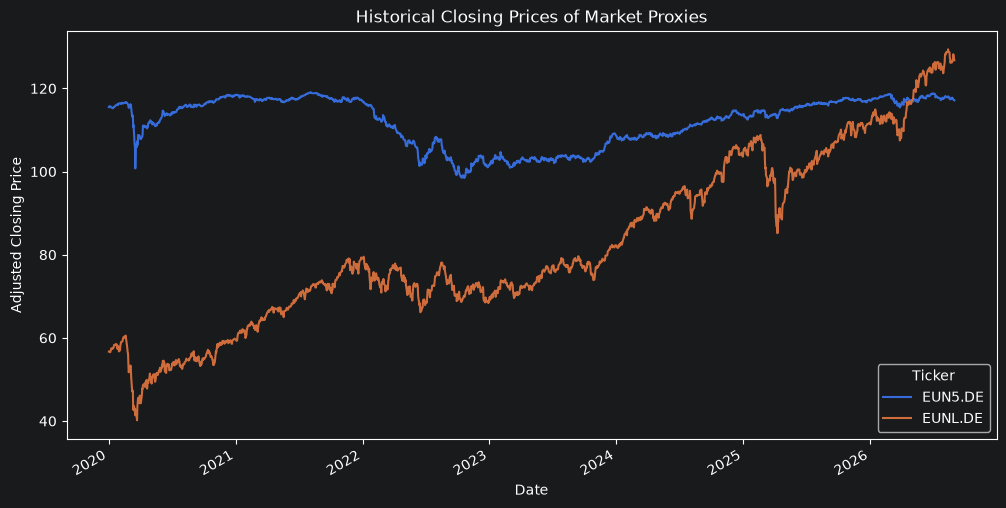

In [12]:
close_prices.plot(
    figsize=(12, 6),
    title="Historical Closing Prices of Market Proxies"
)

plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.show()

## Relative Market Performance

Because the two market proxies have different price levels, their raw prices
cannot be directly compared in terms of investment performance.

Both series are therefore indexed to 100 at the beginning of the sample
period. This allows their relative performance to be compared over time.

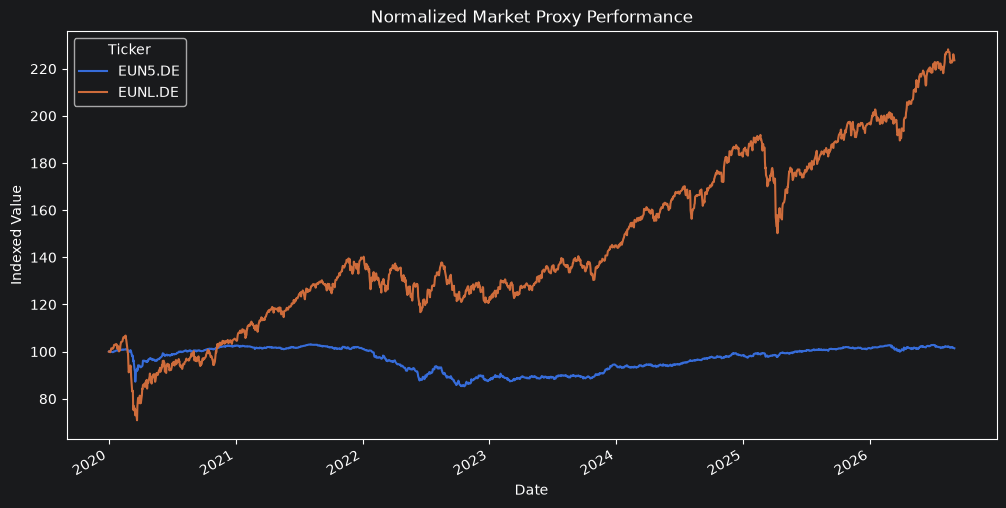

In [13]:
normalized_prices = close_prices / close_prices.iloc[0] * 100

normalized_prices.plot(
    figsize=(12, 6),
    title="Normalized Market Proxy Performance"
)

plt.xlabel("Date")
plt.ylabel("Indexed Value")
plt.show()

In [14]:
normalized_prices.head()

Ticker,EUN5.DE,EUNL.DE
Date,,
2020-01-02,100.000000,100.000000
2020-01-03,100.178554,99.964726
2020-01-06,100.178554,99.735447
2020-01-07,100.119023,100.356260
2020-01-08,100.018608,100.768961


## Return Analysis

Risk analysis is based primarily on changes in asset values rather than their
absolute price levels.

Daily percentage returns are therefore calculated and summarized using basic
descriptive statistics.

In [15]:
returns = close_prices.pct_change().dropna()

returns.head()

Ticker,EUN5.DE,EUNL.DE
Date,,
2020-01-03,0.001786,-0.000353
2020-01-06,0.000000,-0.002294
2020-01-07,-0.000594,0.006225
2020-01-08,-0.001003,0.004112
2020-01-09,-0.000930,0.006301


In [16]:
print(returns.isna().sum())

Ticker
EUN5.DE    0
EUNL.DE    0
dtype: int64


In [17]:
returns.describe()

Ticker,EUN5.DE,EUNL.DE
count,1694.000000,1694.000000
mean,0.000014,0.000529
std,0.003380,0.010382
min,-0.048448,-0.096459
25%,-0.001297,-0.004026
50%,0.000083,0.001020
75%,0.001380,0.005465
max,0.029648,0.082191


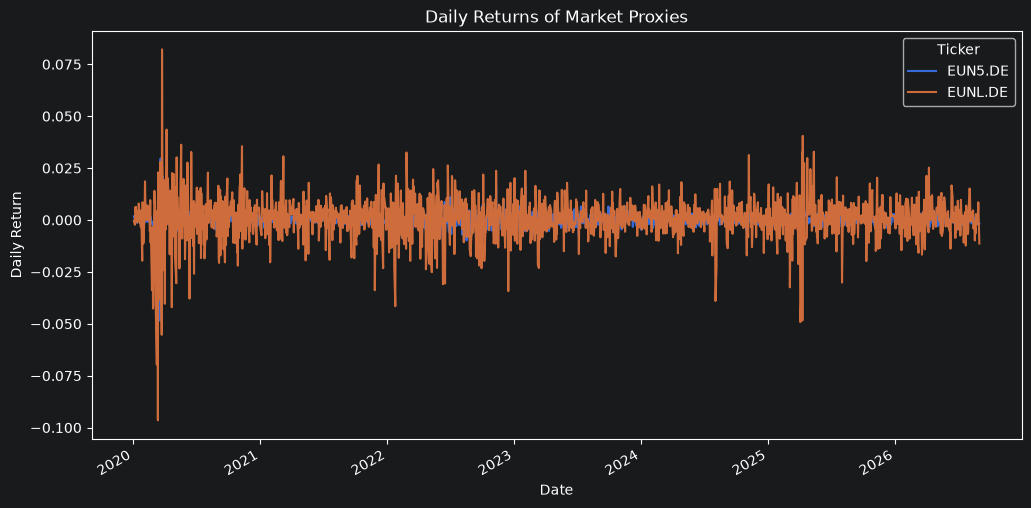

In [18]:
returns.plot(
    figsize=(12, 6),
    title="Daily Returns of Market Proxies"
)

plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

## Risk Characteristics

The variability and interaction of asset returns are examined using
annualized volatility and correlation.

Volatility provides an indication of how strongly an asset's returns vary
over time, while correlation measures how the assets tend to move relative
to each other.

In [19]:
annualized_volatility = returns.std() * np.sqrt(252)

annualized_volatility

Ticker
EUN5.DE    0.053655
EUNL.DE    0.164813
dtype: float64

In [20]:
annualized_volatility.sort_values(ascending=False)

Ticker
EUNL.DE    0.164813
EUN5.DE    0.053655
dtype: float64

In [21]:
correlation_matrix = returns.corr()

correlation_matrix

Ticker,EUN5.DE,EUNL.DE
Ticker,,
EUN5.DE,1.000000,0.402506
EUNL.DE,0.402506,1.000000


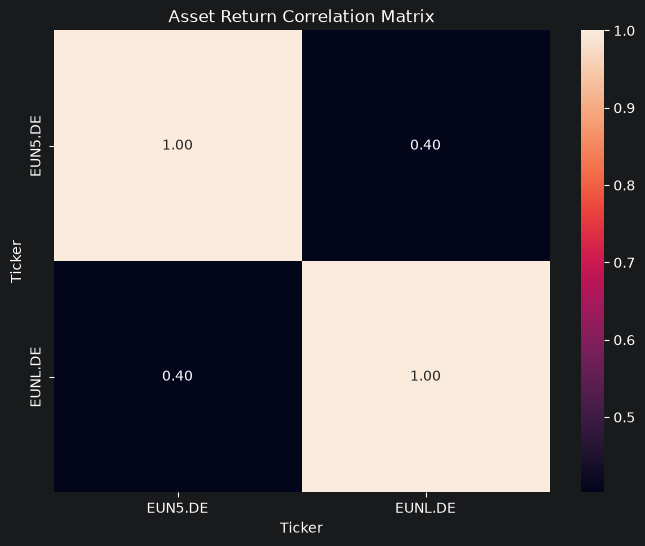

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Asset Return Correlation Matrix")
plt.show()

## Return Distribution

The distribution of daily returns is examined to understand the typical
range of market movements and identify unusually large positive or negative
observations.

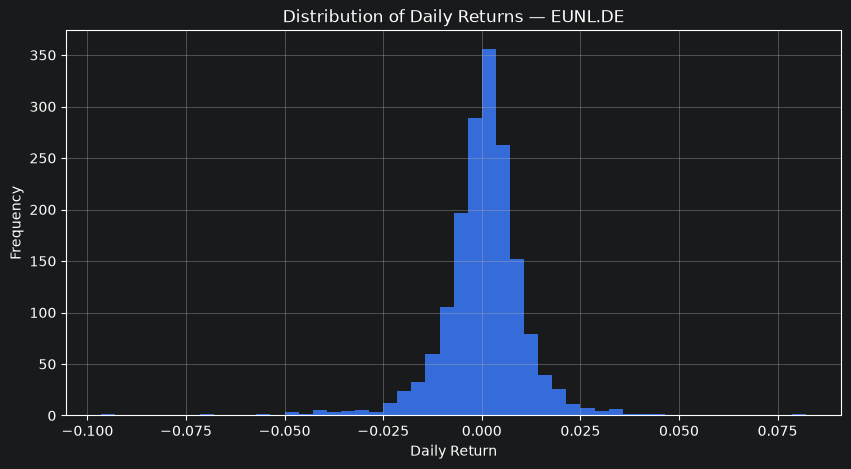

In [23]:
returns["EUNL.DE"].hist(
    bins=50,
    figsize=(10, 5)
)

plt.title("Distribution of Daily Returns — EUNL.DE")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## Cumulative Performance and Drawdown

Cumulative performance shows how an initial investment would have evolved
over the sample period based on the observed daily returns.

Drawdown is then used to measure declines from previous portfolio or asset
peaks and provides an additional perspective on historical downside risk.

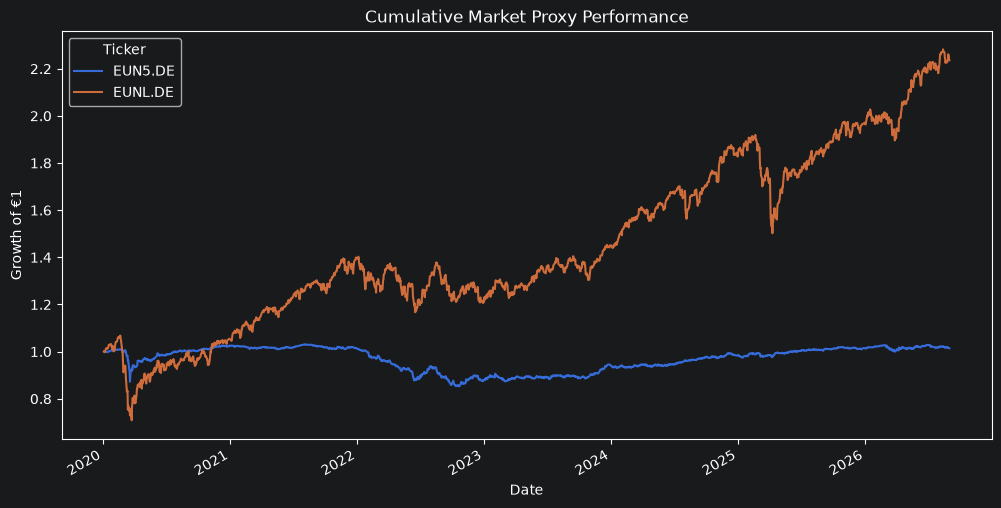

In [24]:
wealth_index = (1 + returns).cumprod()

wealth_index.plot(
    figsize=(12, 6),
    title="Cumulative Market Proxy Performance"
)

plt.xlabel("Date")
plt.ylabel("Growth of €1")
plt.show()

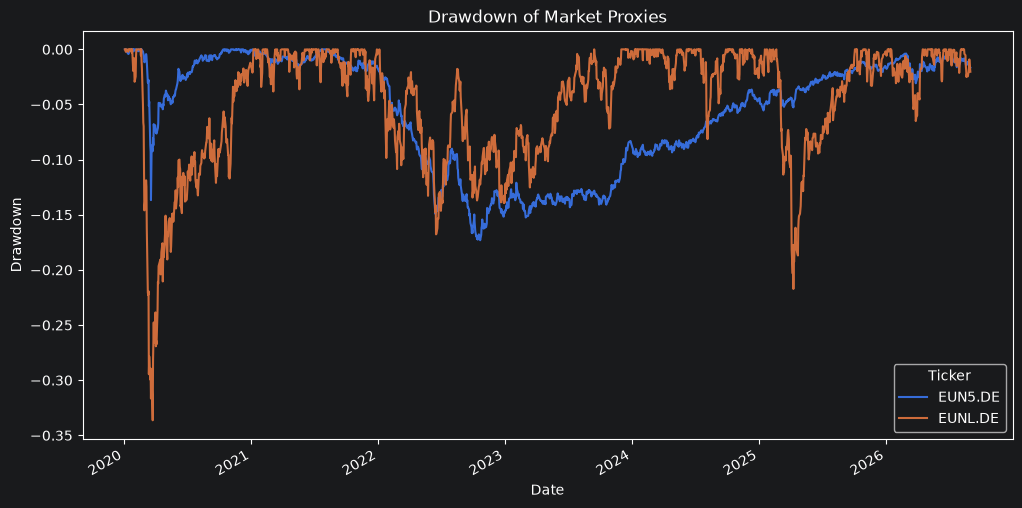

In [25]:
running_max = wealth_index.cummax()

drawdown = wealth_index / running_max - 1

drawdown.plot(
    figsize=(12, 6),
    title="Drawdown of Market Proxies"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

In [26]:
maximum_drawdown = drawdown.min()

maximum_drawdown

Ticker
EUN5.DE   -0.173061
EUNL.DE   -0.336322
dtype: float64

## Initial Risk Summary

The main risk characteristics identified during the exploratory analysis are
summarized below.

These results provide the initial quantitative view of the market proxies
before constructing the portfolio and applying more advanced risk measures.

In [27]:
risk_summary = pd.DataFrame({
    "Annualized Volatility": annualized_volatility,
    "Maximum Drawdown": maximum_drawdown
})

risk_summary

,Annualized Volatility,Maximum Drawdown
Ticker,,
EUN5.DE,0.053655,-0.173061
EUNL.DE,0.164813,-0.336322


## Data Dictionary

| Variable | Description | Role in the Project |
|---|---|---|
| EUNL.DE | iShares Core MSCI World UCITS ETF | Global equity proxy |
| EUN5.DE | iShares Core € Corp Bond UCITS ETF | Euro investment-grade corporate bond proxy |
| Return | Daily percentage change | Main input for risk analysis |
| Volatility | Standard deviation of returns | Market risk measure |
| Correlation | Dependence between asset returns | Portfolio diversification |
| Drawdown | Decline from previous peak | Downside risk |

## Initial Findings

The initial analysis provides a first view of the behavior and risk
characteristics of the selected market proxies.

The dataset has been inspected and prepared, daily returns have been
calculated, and the main characteristics of the assets have been examined
through volatility, correlation, cumulative performance and drawdown.

The next stage will use these return series to construct a diversified
portfolio and evaluate its overall risk.

## Save Processed Data

The cleaned market price series and calculated daily returns are saved for
use in the subsequent stages of the analysis.

In [28]:
from pathlib import Path

# Project directory
project_path = Path(r"C:\Users\Khaled\PycharmProjects\WelcomeScreen")

# Processed data directory
processed_path = project_path / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)

# Save processed datasets
close_prices.to_csv(processed_path / "market_prices_clean.csv")
returns.to_csv(processed_path / "market_returns.csv")

print(f"Processed data saved to: {processed_path}")

Processed data saved to: C:\Users\Khaled\PycharmProjects\WelcomeScreen\data\processed


## Portfolio Construction and Performance

The previous analysis examined the individual risk characteristics of the selected market proxies. The next step is to combine them into a simple illustrative portfolio.

A constant-weight 60/40 allocation is used as a transparent analytical baseline, with 60% allocated to the global equity proxy and 40% to the euro corporate bond proxy.

The portfolio is used as an analytical example and does not represent the actual asset allocation of any specific institution.


In [29]:
# Portfolio weights
weights = pd.Series({
    "EUNL.DE": 0.60,
    "EUN5.DE": 0.40
})

In [30]:
# Calculate the daily return of the 60/40 portfolio
portfolio_returns = returns[weights.index].dot(weights)

print("First portfolio returns:")
print(portfolio_returns.head())
print("\nNumber of portfolio observations:", len(portfolio_returns))

First portfolio returns:
Date
2020-01-03    0.000503
2020-01-06   -0.001376
2020-01-07    0.003497
2020-01-08    0.002066
2020-01-09    0.003408
dtype: float64

Number of portfolio observations: 1694


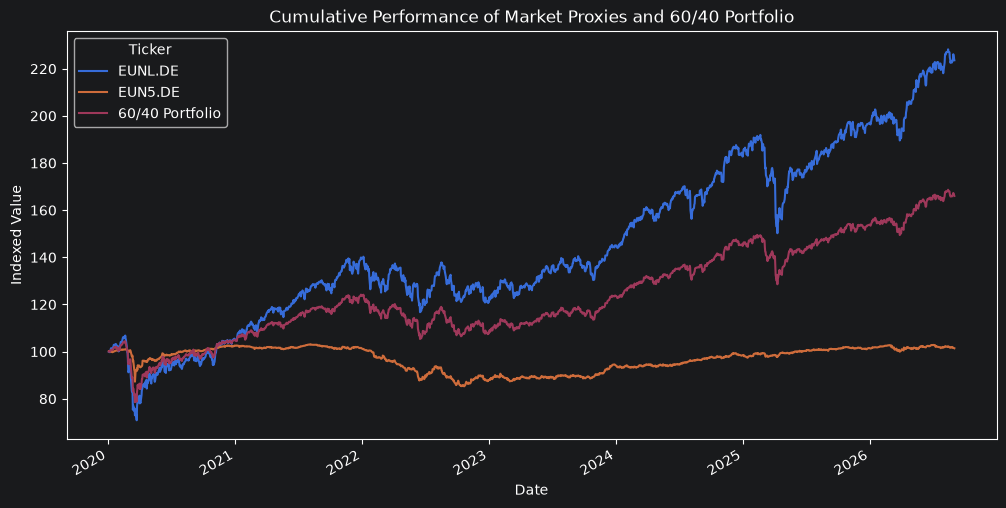

In [31]:
# Convert daily returns into cumulative performance
portfolio_wealth = (1 + portfolio_returns).cumprod() * 100
asset_wealth = (1 + returns[weights.index]).cumprod() * 100

# Combine the series for comparison
performance = asset_wealth.copy()
performance["60/40 Portfolio"] = portfolio_wealth

performance.plot(
    figsize=(12, 6),
    title="Cumulative Performance of Market Proxies and 60/40 Portfolio"
)

plt.xlabel("Date")
plt.ylabel("Indexed Value")
plt.show()

## Portfolio Volatility and Diversification

Portfolio risk depends not only on the individual volatility of each asset, but also on the relationship between their returns.

The portfolio volatility is therefore calculated using the covariance matrix and portfolio weights.

The result is compared with the weighted average volatility of the individual assets to assess the diversification benefit.

In [32]:
# Annualized covariance matrix
covariance_matrix = returns[weights.index].cov() * 252

# Portfolio variance and volatility
portfolio_variance = weights.T @ covariance_matrix @ weights
portfolio_volatility = np.sqrt(portfolio_variance)

# Independent calculation directly from portfolio returns
portfolio_volatility_check = portfolio_returns.std() * np.sqrt(252)

# Weighted average of individual asset volatilities
individual_volatility = returns[weights.index].std() * np.sqrt(252)
weighted_average_volatility = (individual_volatility * weights).sum()

# Diversification benefit
diversification_benefit = (
    weighted_average_volatility - portfolio_volatility
)

print("Annualized individual volatility:")
print(individual_volatility)

print("\nWeighted average volatility:")
print(f"{weighted_average_volatility:.2%}")

print("\nPortfolio volatility:")
print(f"{portfolio_volatility:.2%}")

print("\nPortfolio volatility check:")
print(f"{portfolio_volatility_check:.2%}")

print("\nDiversification benefit:")
print(f"{diversification_benefit:.2%}")

Annualized individual volatility:
Ticker
EUNL.DE    0.164813
EUN5.DE    0.053655
dtype: float64

Weighted average volatility:
12.03%

Portfolio volatility:
10.93%

Portfolio volatility check:
10.93%

Diversification benefit:
1.10%


## Portfolio Drawdown & Rolling Portfolio Volatility

Drawdown measures the decline of an investment from a previous peak.

The portfolio drawdown is calculated to evaluate its historical downside experience and to compare it with the individual market proxies.

A rolling volatility measure is therefore used to observe how the annualized risk of the portfolio changes across different market periods.
A 63-trading-day window is used as an approximate three-month rolling period.

Maximum drawdown of the 60/40 portfolio:
-24.77%


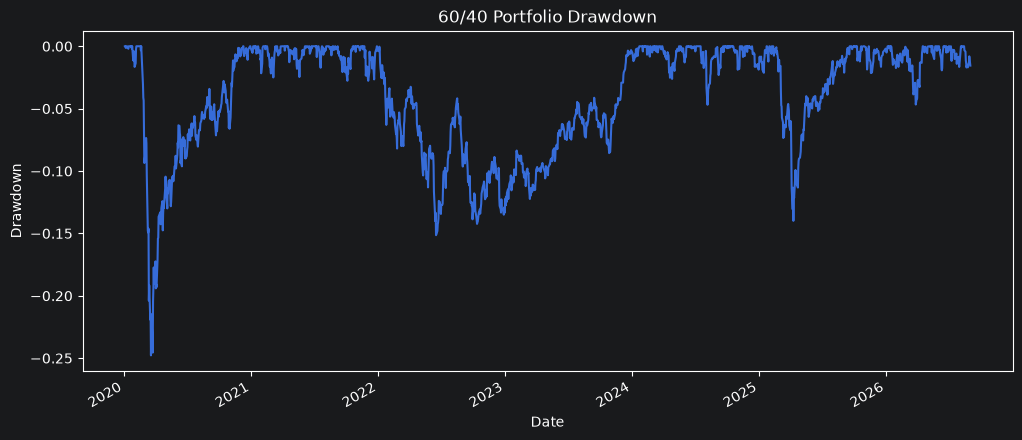

In [33]:
# portfolio drawdown
portfolio_running_max = portfolio_wealth.cummax()

portfolio_drawdown = (
    portfolio_wealth / portfolio_running_max - 1
)

portfolio_max_drawdown = portfolio_drawdown.min()

print("Maximum drawdown of the 60/40 portfolio:")
print(f"{portfolio_max_drawdown:.2%}")

portfolio_drawdown.plot(
    figsize=(12, 5),
    title="60/40 Portfolio Drawdown"
)

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

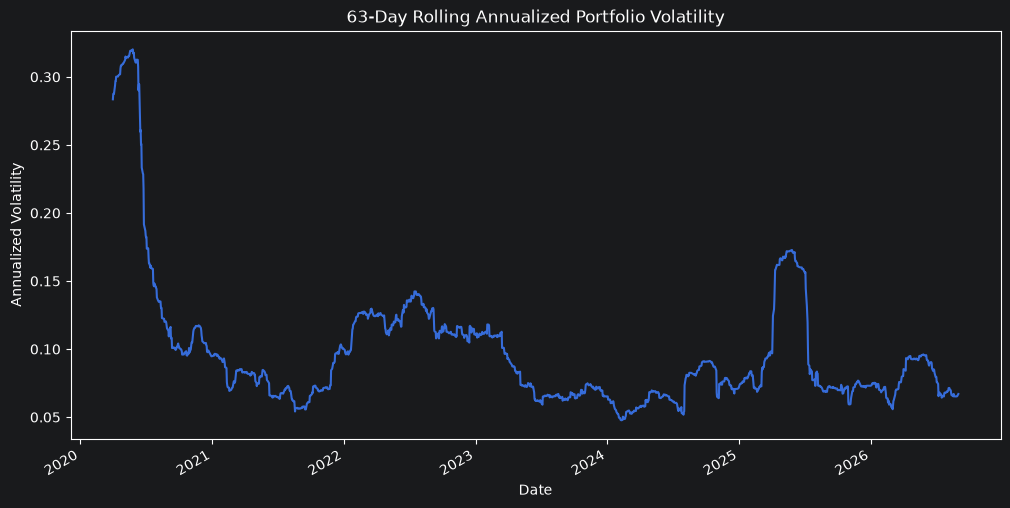

In [34]:
# 3-month rolling annualized volatility
rolling_portfolio_volatility = (
    portfolio_returns.rolling(window=63).std() * np.sqrt(252)
)

rolling_portfolio_volatility.plot(
    figsize=(12, 6),
    title="63-Day Rolling Annualized Portfolio Volatility"
)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.show()

In [35]:
# Portfolio Risk Summary
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Mean Daily Return",
        "Annualized Volatility",
        "Maximum Drawdown",
        "Diversification Benefit"
    ],
    "Value": [
        portfolio_returns.mean(),
        portfolio_volatility,
        portfolio_max_drawdown,
        diversification_benefit
    ]
})

portfolio_summary

,Metric,Value
0,Mean Daily Return,0.000323
1,Annualized Volatility,0.109307
2,Maximum Drawdown,-0.247740
3,Diversification Benefit,0.011043


## Asset and Portfolio Risk Comparison

The individual market proxies are compared with the combined portfolio using annualized volatility and maximum drawdown.

The comparison highlights how combining assets with different risk characteristics can change the overall portfolio risk profile.

In [36]:
# individual maximum drawdowns
asset_wealth = (1 + returns[weights.index]).cumprod()
asset_running_max = asset_wealth.cummax()
asset_drawdown = asset_wealth / asset_running_max - 1
asset_max_drawdown = asset_drawdown.min()

# comparison table
risk_comparison = pd.DataFrame({
    "Annualized Volatility": individual_volatility,
    "Maximum Drawdown": asset_max_drawdown
})

risk_comparison.loc["60/40 Portfolio"] = [
    portfolio_volatility,
    portfolio_max_drawdown
]

risk_comparison

,Annualized Volatility,Maximum Drawdown
Ticker,,
EUNL.DE,0.164813,-0.336322
EUN5.DE,0.053655,-0.173061
60/40 Portfolio,0.109307,-0.247740


In [37]:
# Save Portfolio Data
portfolio_returns.to_csv(
    processed_path / "portfolio_returns.csv"
)

weights.rename("Weight").to_csv(
    processed_path / "portfolio_weights.csv"
)

portfolio_summary.to_csv(
    processed_path / "portfolio_risk_summary.csv",
    index=False
)

risk_comparison.to_csv(
    processed_path / "asset_portfolio_risk_comparison.csv"
)

print(f"Portfolio data saved to: {processed_path}")

Portfolio data saved to: C:\Users\Khaled\PycharmProjects\WelcomeScreen\data\processed


## Portfolio Loss Distribution

The portfolio returns are now used to examine downside risk and estimate potential losses under historical market conditions.

In [38]:
portfolio_returns.describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])

count    1694.000000
mean        0.000323
std         0.006886
min        -0.067564
1%         -0.023229
5%         -0.009904
50%         0.000667
95%         0.009833
99%         0.018597
max         0.054512
dtype: float64

In [39]:
# Estimate historical VaR at 95% and 99%
var_95 = -portfolio_returns.quantile(0.05)
var_99 = -portfolio_returns.quantile(0.01)

print(f"Historical VaR (95%): {var_95:.2%}")
print(f"Historical VaR (99%): {var_99:.2%}")

Historical VaR (95%): 0.99%
Historical VaR (99%): 2.32%


In [40]:
# Convert VaR into a monetary amount
portfolio_value = 1_000_000

var_95_amount = portfolio_value * var_95
var_99_amount = portfolio_value * var_99

print(f"95% VaR: €{var_95_amount:,.0f}")
print(f"99% VaR: €{var_99_amount:,.0f}")

95% VaR: €9,904
99% VaR: €23,229


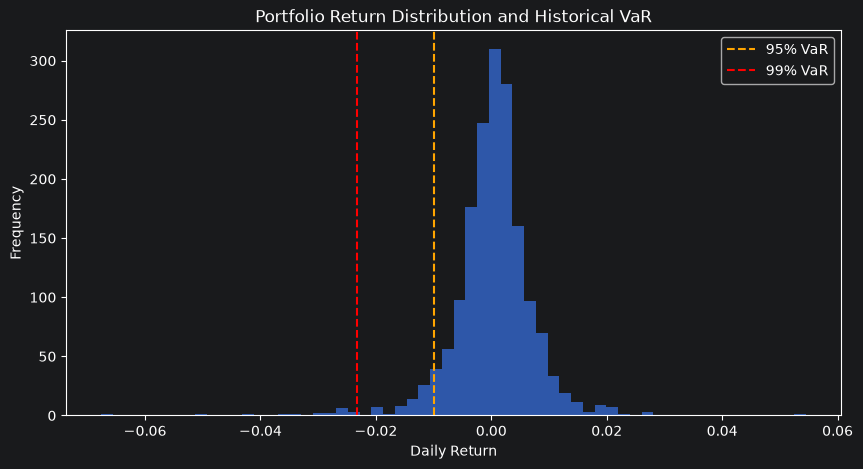

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(
    portfolio_returns.dropna(),
    bins=60,
    alpha=0.75
)

plt.axvline(
    -var_95,
    linestyle="--",
    color="orange",
    label="95% VaR"
)

plt.axvline(
    -var_99,
    linestyle="--",
    color="red",
    label="99% VaR"
)

plt.title("Portfolio Return Distribution and Historical VaR")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [42]:
# Identify the largest daily portfolio losses
worst_days = portfolio_returns.sort_values().head(10)

worst_days

Date
2020-03-12   -0.067564
2020-03-09   -0.049445
2020-03-18   -0.042414
2020-03-23   -0.035472
2020-03-16   -0.034016
2025-04-09   -0.029944
2025-04-03   -0.029582
2020-03-06   -0.028011
2025-04-04   -0.027863
2020-02-27   -0.026799
dtype: float64

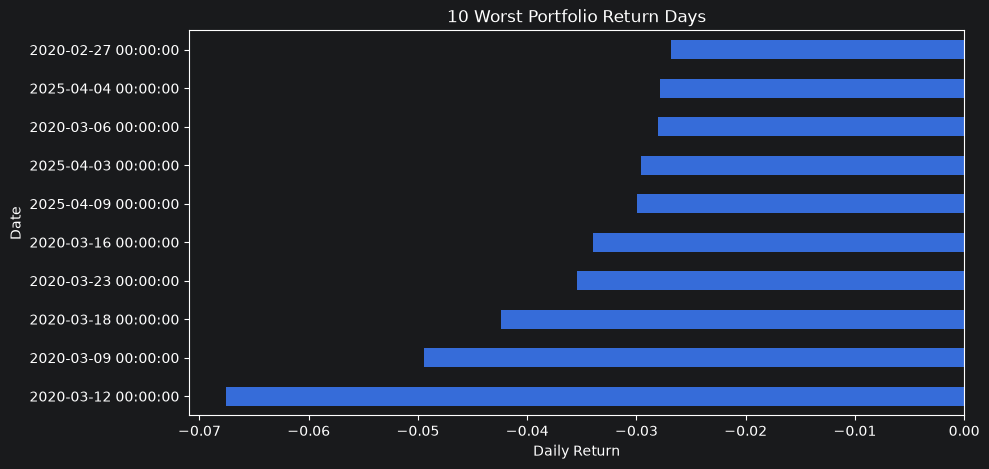

In [43]:
worst_days.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    title="10 Worst Portfolio Return Days"
)

plt.xlabel("Daily Return")
plt.ylabel("Date")
plt.show()

In [44]:
# Check how often actual losses exceeded the VaR thresholds
var_95_breaches = (portfolio_returns < -var_95).sum()
var_99_breaches = (portfolio_returns < -var_99).sum()

print(f"95% VaR breaches: {var_95_breaches}")
print(f"99% VaR breaches: {var_99_breaches}")

95% VaR breaches: 85
99% VaR breaches: 17


### VaR Backtesting — Kupiec Proportion of Failures Test

The simple breach count above shows that actual losses exceeded the 95% VaR
threshold on 85 out of 1,694 trading days (≈5.02%) and the 99% VaR on 17
occasions (≈1.00%) — both remarkably close to their theoretical
expectations. The Kupiec Proportion of Failures (POF) test formally
evaluates whether this level of agreement is statistically acceptable,
using a likelihood ratio test under the null hypothesis that the model is
correctly calibrated.

In [1]:
from scipy.stats import chi2

def kupiec_test(n_breaches, n_observations, confidence_level):
    p = 1 - confidence_level
    p_hat = n_breaches / n_observations

    numerator = (1 - p) ** (n_observations - n_breaches) * p ** n_breaches
    denominator = (1 - p_hat) ** (n_observations - n_breaches) * p_hat ** n_breaches

    lr_stat = -2 * np.log(numerator / denominator)
    p_value = 1 - chi2.cdf(lr_stat, df=1)

    return lr_stat, p_value

lr_95, pvalue_95 = kupiec_test(var_95_breaches, len(portfolio_returns), 0.95)
lr_99, pvalue_99 = kupiec_test(var_99_breaches, len(portfolio_returns), 0.99)

kupiec_summary = pd.DataFrame({
    "VaR Level": ["95%", "99%"],
    "LR Statistic": [lr_95, lr_99],
    "P-value": [pvalue_95, pvalue_99],
    "Conclusion": [
        "Do not reject correct coverage" if pvalue_95 > 0.05 else "Reject correct coverage",
        "Do not reject correct coverage" if pvalue_99 > 0.05 else "Reject correct coverage"
    ]
})

kupiec_summary

  VaR Level  LR Statistic   P-value                      Conclusion
0       95%      0.001117  0.973335  Do not reject correct coverage
1       99%      0.000214  0.988317  Do not reject correct coverage

## Expected Shortfall

VaR identifies a loss threshold, while Expected Shortfall measures the average loss beyond that threshold. This provides a clearer view of tail risk.

In [46]:
# Measure the average loss beyond the VaR threshold
es_95 = -portfolio_returns[portfolio_returns <= -var_95].mean()
es_99 = -portfolio_returns[portfolio_returns <= -var_99].mean()

print(f"Historical ES (95%): {es_95:.2%}")
print(f"Historical ES (99%): {es_99:.2%}")

Historical ES (95%): 1.71%
Historical ES (99%): 3.23%


In [47]:
risk_summary = pd.DataFrame({
    "95%": [var_95, es_95],
    "99%": [var_99, es_99]
}, index=["VaR", "Expected Shortfall"])

risk_summary

,95%,99%
VaR,0.009904,0.023229
Expected Shortfall,0.017143,0.032321


In [48]:
es_95_amount = portfolio_value * es_95
es_99_amount = portfolio_value * es_99

print(f"95% Expected Shortfall: €{es_95_amount:,.0f}")
print(f"99% Expected Shortfall: €{es_99_amount:,.0f}")

95% Expected Shortfall: €17,143
99% Expected Shortfall: €32,321


In [49]:
tail_95 = portfolio_returns[portfolio_returns <= -var_95]

print(f"Number of observations in 95% tail: {len(tail_95)}")
print(f"Average loss in 95% tail: {tail_95.mean():.2%}")
print(f"Worst loss in 95% tail: {tail_95.min():.2%}")

Number of observations in 95% tail: 85
Average loss in 95% tail: -1.71%
Worst loss in 95% tail: -6.76%


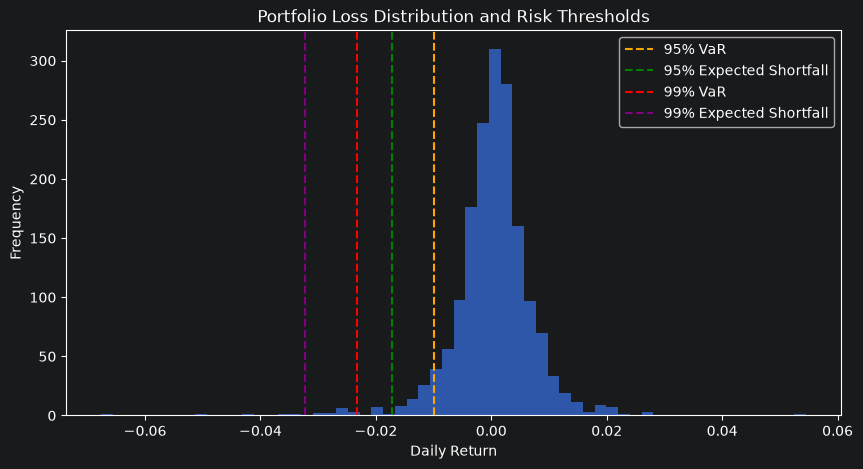

In [50]:
# Compare VaR and Expected Shortfall on the return distribution
plt.figure(figsize=(10, 5))

plt.hist(
    portfolio_returns.dropna(),
    bins=60,
    alpha=0.75
)

plt.axvline(
    -var_95,
    linestyle="--",
    color="orange",
    label="95% VaR"
)

plt.axvline(
    -es_95,
    linestyle="--",
    color="green",
    label="95% Expected Shortfall"
)

plt.axvline(
    -var_99,
    linestyle="--",
    color="red",
    label="99% VaR"
)

plt.axvline(
    -es_99,
    linestyle="--",
    color="purple",
    label="99% Expected Shortfall"
)

plt.title("Portfolio Loss Distribution and Risk Thresholds")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [51]:
tail_severity = es_95 / var_95

print(f"ES / VaR ratio at 95%: {tail_severity:.2f}")

ES / VaR ratio at 95%: 1.73


In [52]:
risk_summary = pd.DataFrame({
    "95%": [var_95, es_95],
    "99%": [var_99, es_99]
}, index=["Historical VaR", "Historical ES"])

risk_summary

,95%,99%
Historical VaR,0.009904,0.023229
Historical ES,0.017143,0.032321


In [53]:
risk_summary_amount = risk_summary * portfolio_value

risk_summary_amount

,95%,99%
Historical VaR,9903.845612,23229.033615
Historical ES,17143.107092,32320.687760


## Historical Stress Testing

Instead of assuming arbitrary market shocks, we first examine how the portfolio would have behaved during severe historical market conditions.

The scenarios are based on actual periods in the sample and allow us to compare the portfolio response across different types of market stress.

In [54]:
returns.loc["2025-03-01":"2025-04-15"]

Ticker,EUN5.DE,EUNL.DE
Date,,
2025-03-03,-0.001285,0.002274
2025-03-04,-0.001744,-0.032430
2025-03-05,-0.007653,-0.015244
2025-03-06,-0.004946,0.001985
2025-03-07,0.003033,-0.018094
2025-03-10,0.002352,-0.007746
2025-03-11,-0.004483,-0.019577
2025-03-12,-0.000379,0.010140
2025-03-13,-0.001389,-0.006856


In [55]:
# Historical stress periods

historical_scenarios = {
    "COVID-19 Crash": ("2020-02-19", "2020-03-23"),
    "COVID Crash + Partial Recovery Window": ("2020-02-19", "2020-04-30"),
    "2022 Rate & Inflation Shock": ("2022-01-03", "2022-06-16"),
    "2022 Stock-Bond Selloff": ("2022-01-03", "2022-10-12"),
    "2025 Tariff Shock": ("2025-04-02", "2025-04-09")
}

historical_results = []

for scenario, (start, end) in historical_scenarios.items():
    period_returns = returns.loc[start:end]

    equity_return = (1 + period_returns["EUNL.DE"]).prod() - 1
    bond_return = (1 + period_returns["EUN5.DE"]).prod() - 1

    portfolio_return = (
        0.60 * equity_return +
        0.40 * bond_return
    )

    historical_results.append({
        "Scenario": scenario,
        "Equity Return": equity_return,
        "Bond Return": bond_return,
        "Portfolio Return": portfolio_return
    })

historical_results = pd.DataFrame(historical_results)

historical_results

,Scenario,Equity Return,Bond Return,Portfolio Return
0,COVID-19 Crash,-0.329971,-0.091309,-0.234506
1,COVID Crash + Partial Recovery Window,-0.157091,-0.036272,-0.108763
2,2022 Rate & Inflation Shock,-0.164753,-0.132069,-0.151679
3,2022 Stock-Bond Selloff,-0.133912,-0.157673,-0.143416
4,2025 Tariff Shock,-0.133847,-0.009319,-0.084036


### Portfolio Impact Across Historical Stress Periods

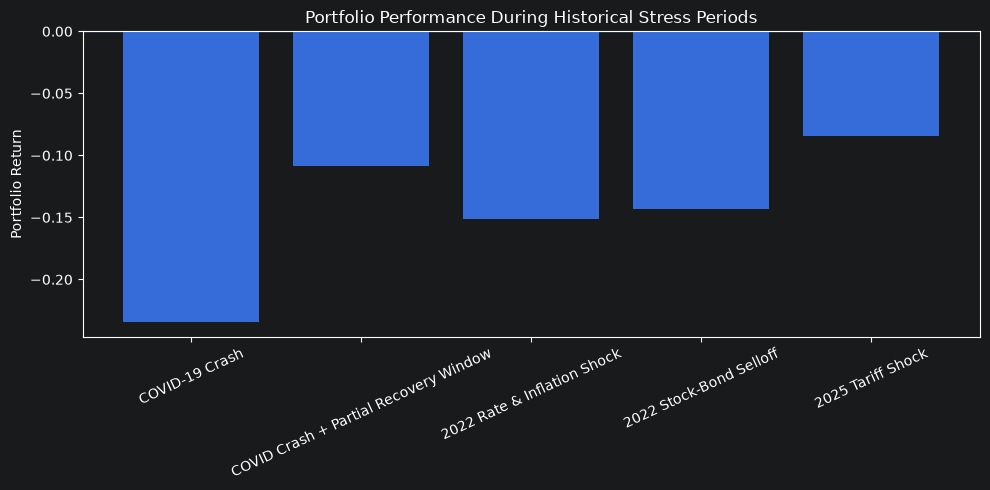

In [56]:
plt.figure(figsize=(10, 5))

plt.bar(
    historical_results["Scenario"],
    historical_results["Portfolio Return"]
)

plt.axhline(0, linewidth=1)

plt.ylabel("Portfolio Return")
plt.title("Portfolio Performance During Historical Stress Periods")
plt.xticks(rotation=25)
plt.tight_layout()

plt.show()

### Worst Historical Scenario

We identify the historical period that produced the largest portfolio loss.

In [57]:
worst_scenario = historical_results.loc[
    historical_results["Portfolio Return"].idxmin()
]

worst_scenario

Scenario            COVID-19 Crash
Equity Return            -0.329971
Bond Return              -0.091309
Portfolio Return         -0.234506
Name: 0, dtype: object

### Worst Scenario: Asset Contribution

In [58]:
worst_equity = worst_scenario["Equity Return"]
worst_bond = worst_scenario["Bond Return"]

equity_contribution = 0.60 * worst_equity
bond_contribution = 0.40 * worst_bond

contribution_table = pd.DataFrame({
    "Component": ["Equity", "Bonds"],
    "Portfolio Contribution": [
        equity_contribution,
        bond_contribution
    ]
})

contribution_table

,Component,Portfolio Contribution
0,Equity,-0.197983
1,Bonds,-0.036524


## Hypothetical Stress Testing

Historical scenarios show what has happened before. We now extend the analysis by applying more severe hypothetical shocks based on the observed historical stress in the data.

In [59]:
worst_equity_return = returns["EUNL.DE"].min()
worst_bond_return = returns["EUN5.DE"].min()

print(f"Worst daily equity return: {worst_equity_return:.2%}")
print(f"Worst daily bond return: {worst_bond_return:.2%}")

Worst daily equity return: -9.65%
Worst daily bond return: -4.84%


### Hypothetical Stress Scenarios

The hypothetical scenarios scale the worst observed daily market movements to represent moderate, severe and extreme stress conditions.

In [60]:
stress_multipliers = {
    "Moderate Stress": 1.0,
    "Severe Stress": 1.5,
    "Extreme Stress": 2.0
}

hypothetical_results = []

for scenario, multiplier in stress_multipliers.items():

    equity_stress = worst_equity_return * multiplier
    bond_stress = worst_bond_return * multiplier

    portfolio_stress = (
        0.60 * equity_stress +
        0.40 * bond_stress
    )

    hypothetical_results.append({
        "Scenario": scenario,
        "Equity Shock": equity_stress,
        "Bond Shock": bond_stress,
        "Portfolio Impact": portfolio_stress
    })

hypothetical_results = pd.DataFrame(hypothetical_results)

hypothetical_results

,Scenario,Equity Shock,Bond Shock,Portfolio Impact
0,Moderate Stress,-0.096459,-0.048448,-0.077254
1,Severe Stress,-0.144688,-0.072671,-0.115882
2,Extreme Stress,-0.192918,-0.096895,-0.154509


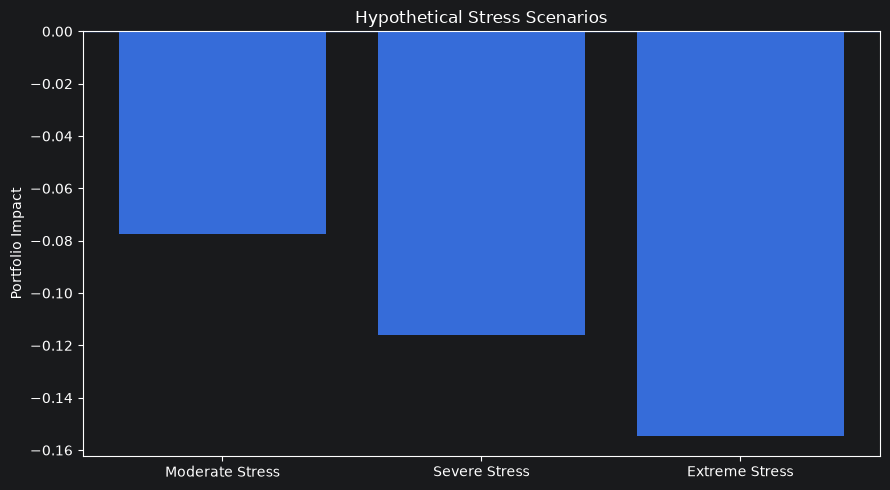

In [61]:
plt.figure(figsize=(9, 5))

plt.bar(
    hypothetical_results["Scenario"],
    hypothetical_results["Portfolio Impact"]
)

plt.axhline(0, linewidth=1)

plt.ylabel("Portfolio Impact")
plt.title("Hypothetical Stress Scenarios")

plt.tight_layout()
plt.show()

## Historical vs Hypothetical Stress

The final comparison shows the difference between losses observed during historical stress periods and losses under the more severe hypothetical scenarios.

In [62]:
historical_comparison = historical_results[
    ["Scenario", "Portfolio Return"]
].copy()

historical_comparison.columns = [
    "Scenario",
    "Portfolio Impact"
]

hypothetical_comparison = hypothetical_results[
    ["Scenario", "Portfolio Impact"]
].copy()

stress_comparison = pd.concat(
    [historical_comparison, hypothetical_comparison],
    ignore_index=True
)

stress_comparison

,Scenario,Portfolio Impact
0,COVID-19 Crash,-0.234506
1,COVID Crash + Partial Recovery Window,-0.108763
2,2022 Rate & Inflation Shock,-0.151679
3,2022 Stock-Bond Selloff,-0.143416
4,2025 Tariff Shock,-0.084036
5,Moderate Stress,-0.077254
6,Severe Stress,-0.115882
7,Extreme Stress,-0.154509


### Stress Test Comparison

*Note: historical scenarios reflect cumulative multi-week losses, while hypothetical scenarios scale a single worst-day shock — the two are not directly comparable in time horizon, only in magnitude.*


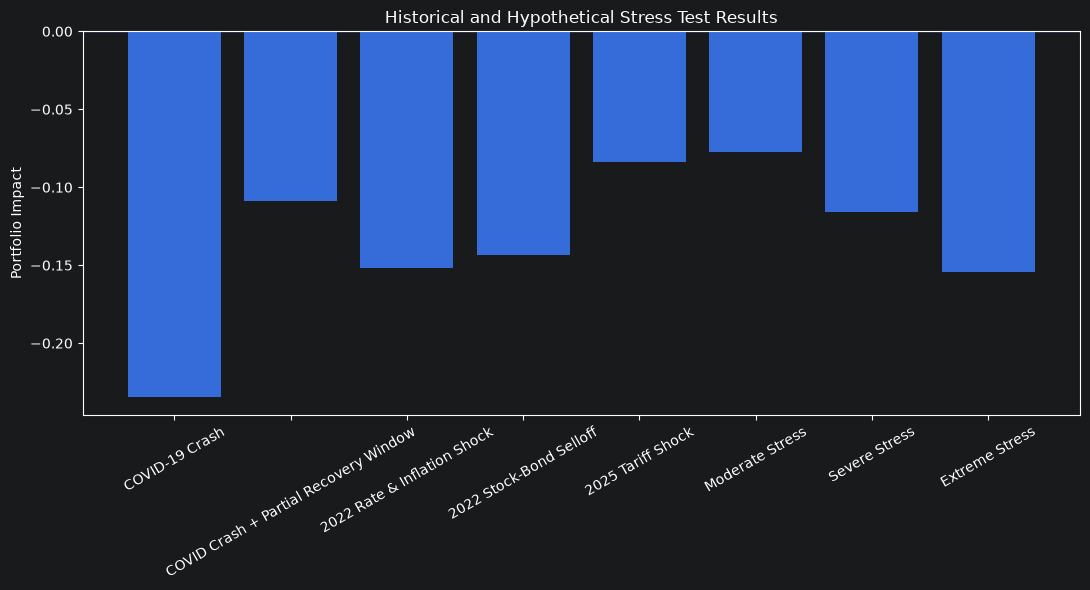

In [63]:
plt.figure(figsize=(11, 6))

plt.bar(
    stress_comparison["Scenario"],
    stress_comparison["Portfolio Impact"]
)

plt.axhline(0, linewidth=1)

plt.ylabel("Portfolio Impact")
plt.title("Historical and Hypothetical Stress Test Results")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Stress Testing Findings

The stress testing analysis shows how the portfolio responds under both historical and hypothetical market stress.

Historical scenarios highlight the portfolio's actual behaviour during severe market conditions, while the hypothetical scenarios illustrate how losses could increase under more extreme shocks.

The comparison also helps identify whether equity or fixed-income exposure is the main contributor to portfolio losses during stressed periods.

In [64]:
print("Worst historical scenario:")
print(worst_scenario["Scenario"])

print(f"\nPortfolio impact:")
print(f"{worst_scenario['Portfolio Return']:.2%}")

Worst historical scenario:
COVID-19 Crash

Portfolio impact:
-23.45%


### Risk Measure Comparison

The stress results are compared with VaR and Expected Shortfall to put the portfolio losses into context.

In [65]:
risk_comparison = pd.DataFrame({
    "Risk Measure": [
        "VaR 95%",
        "Expected Shortfall 95%",
        "VaR 99%",
        "Expected Shortfall 99%",
        "Worst Historical Stress"
    ],
    "Portfolio Impact": [
        -var_95,
        -es_95,
        -var_99,
        -es_99,
        worst_scenario["Portfolio Return"]
    ]
})

risk_comparison

,Risk Measure,Portfolio Impact
0,VaR 95%,-0.009904
1,Expected Shortfall 95%,-0.017143
2,VaR 99%,-0.023229
3,Expected Shortfall 99%,-0.032321
4,Worst Historical Stress,-0.234506


## Market Factor Analysis

To understand what drives portfolio risk, I compare the portfolio with a few broader market factors.

In [66]:
import yfinance as yf

factor_tickers = {
    "S&P 500": "^GSPC",
    "VIX": "^VIX",
    "US 10Y Yield": "^TNX",
    "EUR/USD": "EURUSD=X"
}

factor_data = yf.download(
    list(factor_tickers.values()),
    start="2020-01-01",
    end="2026-09-01",
    auto_adjust=False,
    progress=False
)

factor_data.head()

Price      Adj Close                                Close                      \
Ticker      EURUSD=X        ^GSPC   ^TNX   ^VIX  EURUSD=X        ^GSPC   ^TNX   
Date                                                                            
2020-01-01  1.122083          NaN    NaN    NaN  1.122083          NaN    NaN   
2020-01-02  1.122083  3257.850098  1.882  12.47  1.122083  3257.850098  1.882   
2020-01-03  1.117144  3234.850098  1.788  14.02  1.117144  3234.850098  1.788   
2020-01-06  1.116196  3246.280029  1.811  13.85  1.116196  3246.280029  1.811   
2020-01-07  1.119799  3237.179932  1.827  13.79  1.119799  3237.179932  1.827   

Price                  High               ...    Low             Open  \
Ticker       ^VIX  EURUSD=X        ^GSPC  ...   ^TNX   ^VIX  EURUSD=X   
Date                                      ...                           
2020-01-01    NaN  1.122838          NaN  ...    NaN    NaN  1.122083   
2020-01-02  12.47  1.122712  3258.139893  ...  1.851  12.42  1.121894   
2020-01-03  14.02  1.118068  3246.149902  ...  1.786  13.13  1.117081   
2020-01-06  13.85  1.120825  3246.840088  ...  1.766  13.54  1.116246   
2020-01-07  13.79  1.119946  3244.909912  ...  1.797  13.39  1.119583   

Price                                   Volume                          
Ticker            ^GSPC   ^TNX   ^VIX EURUSD=X         ^GSPC ^TNX ^VIX  
Date                                                                    
2020-01-01          NaN    NaN    NaN      0.0           NaN  NaN  NaN  
2020-01-02  3244.669922  1.903  13.46      0.0  3.459930e+09  0.0  0.0  
2020-01-03  3226.360107  1.828  15.01      0.0  3.484700e+09  0.0  0.0  
2020-01-06  3217.550049  1.785  15.45      0.0  3.702460e+09  0.0  0.0  
2020-01-07  3241.860107  1.797  13.84      0.0  3.435910e+09  0.0  0.0  

[5 rows x 24 columns]

In [67]:
factor_close = factor_data["Close"].copy()

ticker_to_name = {v: k for k, v in factor_tickers.items()}
factor_close = factor_close.rename(columns=ticker_to_name)

factor_close = factor_close[list(factor_tickers.keys())]

factor_close.head()

Ticker,S&P 500,VIX,US 10Y Yield,EUR/USD
Date,,,,
2020-01-01,NaN,NaN,NaN,1.122083
2020-01-02,3257.850098,12.47,1.882,1.122083
2020-01-03,3234.850098,14.02,1.788,1.117144
2020-01-06,3246.280029,13.85,1.811,1.116196
2020-01-07,3237.179932,13.79,1.827,1.119799


In [68]:
# factor returns
factor_returns = factor_close.pct_change().dropna()

factor_returns.head()

Ticker,S&P 500,VIX,US 10Y Yield,EUR/USD
Date,,,,
2020-01-03,-0.007060,0.124298,-0.049947,-0.004401
2020-01-06,0.003533,-0.012126,0.012864,-0.000848
2020-01-07,-0.002803,-0.004332,0.008835,0.003228
2020-01-08,0.004902,-0.024656,0.025725,-0.003863
2020-01-09,0.006655,-0.067658,-0.008538,-0.003723


In [69]:
# Combine portfolio and factors
analysis_data = pd.concat(
    [
        portfolio_returns.rename("Portfolio"),
        factor_returns
    ],
    axis=1
).dropna()

analysis_data.head()

C:\Users\Khaled\AppData\Local\Temp\ipykernel_1888\3211882199.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  analysis_data = pd.concat(


,Portfolio,S&P 500,VIX,US 10Y Yield,EUR/USD
Date,,,,,
2020-01-03,0.000503,-0.007060,0.124298,-0.049947,-0.004401
2020-01-06,-0.001376,0.003533,-0.012126,0.012864,-0.000848
2020-01-07,0.003497,-0.002803,-0.004332,0.008835,0.003228
2020-01-08,0.002066,0.004902,-0.024656,0.025725,-0.003863
2020-01-09,0.003408,0.006655,-0.067658,-0.008538,-0.003723


In [70]:
factor_correlation = analysis_data.corr()["Portfolio"].drop("Portfolio").sort_values()

factor_correlation

VIX            -0.427681
EUR/USD        -0.021534
US 10Y Yield    0.159886
S&P 500         0.603021
Name: Portfolio, dtype: float64

## Interest Rate Duration Shock

Insurance and reinsurance companies are highly sensitive to interest rate
movements due to the long-term nature of their liabilities. This section
estimates the approximate impact of a parallel interest rate shift on the
bond component of the portfolio (EUN5.DE), using a simplified duration-based
approximation:

ΔPrice ≈ − Duration × ΔYield

An approximate modified duration of 5.5 years is assumed, consistent with a
short-to-medium-term euro corporate bond fund such as EUN5.DE.

In [71]:
bond_duration = 5.5

rate_shocks = {
    "+50bps": 0.005,
    "+100bps": 0.01,
    "+200bps": 0.02
}

duration_shock_results = []

for scenario, rate_change in rate_shocks.items():
    bond_price_impact = -bond_duration * rate_change
    portfolio_impact = 0.40 * bond_price_impact

    duration_shock_results.append({
        "Scenario": scenario,
        "Bond Price Impact": bond_price_impact,
        "Portfolio Impact": portfolio_impact
    })

duration_shock_results = pd.DataFrame(duration_shock_results)
duration_shock_results

,Scenario,Bond Price Impact,Portfolio Impact
0,+50bps,-0.0275,-0.011
1,+100bps,-0.0550,-0.022
2,+200bps,-0.1100,-0.044


## Factor-Based Stress Scenario: VIX Spike

The portfolio shows a correlation of -0.43 with the VIX index. Using a
simple linear sensitivity (beta) estimated from historical data, we project
the potential portfolio impact of a sharp spike in market volatility.

In [72]:
vix_beta = (
    analysis_data["VIX"].cov(analysis_data["Portfolio"])
    / analysis_data["VIX"].var()
)

print(f"Portfolio sensitivity to VIX changes (beta): {vix_beta:.4f}")

vix_spike_scenarios = {
    "VIX +50%": 0.50,
    "VIX +100%": 1.00,
    "VIX +200%": 2.00
}

vix_stress_results = []

for scenario, vix_change in vix_spike_scenarios.items():
    estimated_impact = vix_beta * vix_change
    vix_stress_results.append({
        "Scenario": scenario,
        "Estimated Portfolio Impact": estimated_impact
    })

pd.DataFrame(vix_stress_results)

Portfolio sensitivity to VIX changes (beta): -0.0362


,Scenario,Estimated Portfolio Impact
0,VIX +50%,-0.018081
1,VIX +100%,-0.036162
2,VIX +200%,-0.072325


## Value at Risk

VaR gives an estimate of a loss threshold under normal market conditions.

In [73]:
historical_var_95 = portfolio_returns.quantile(0.05)
historical_var_99 = portfolio_returns.quantile(0.01)

print(f"Historical VaR (95%): {historical_var_95:.2%}")
print(f"Historical VaR (99%): {historical_var_99:.2%}")

Historical VaR (95%): -0.99%
Historical VaR (99%): -2.32%


In [74]:
from scipy.stats import norm

portfolio_mean = portfolio_returns.mean()
portfolio_std = portfolio_returns.std()

z_95 = norm.ppf(0.05)
z_99 = norm.ppf(0.01)

parametric_var_95 = portfolio_mean + z_95 * portfolio_std
parametric_var_99 = portfolio_mean + z_99 * portfolio_std

print(f"Parametric VaR (95%): {parametric_var_95:.2%}")
print(f"Parametric VaR (99%): {parametric_var_99:.2%}")

Parametric VaR (95%): -1.10%
Parametric VaR (99%): -1.57%


In [75]:
# Compare VaR methods
var_comparison = pd.DataFrame({
    "Method": [
        "Historical VaR",
        "Parametric VaR"
    ],
    "95% VaR": [
        historical_var_95,
        parametric_var_95
    ],
    "99% VaR": [
        historical_var_99,
        parametric_var_99
    ]
})

var_comparison

,Method,95% VaR,99% VaR
0,Historical VaR,-0.009904,-0.023229
1,Parametric VaR,-0.011003,-0.015695


In [76]:
# VaR versus historical stress
stress_var_comparison = historical_results[
    ["Scenario", "Portfolio Return"]
].copy()

stress_var_comparison["VaR 95%"] = historical_var_95
stress_var_comparison["VaR 99%"] = historical_var_99

stress_var_comparison

,Scenario,Portfolio Return,VaR 95%,VaR 99%
0,COVID-19 Crash,-0.234506,-0.009904,-0.023229
1,COVID Crash + Partial Recovery Window,-0.108763,-0.009904,-0.023229
2,2022 Rate & Inflation Shock,-0.151679,-0.009904,-0.023229
3,2022 Stock-Bond Selloff,-0.143416,-0.009904,-0.023229
4,2025 Tariff Shock,-0.084036,-0.009904,-0.023229


## Monte Carlo simulation

I use Monte Carlo simulation to generate a large number of possible one-day portfolio returns and examine the resulting loss distribution.

In [77]:
import numpy as np

np.random.seed(42)

n_simulations = 10000

simulated_returns = np.random.normal(
    portfolio_mean,
    portfolio_std,
    n_simulations
)

simulated_returns[:10]

array([ 0.00374337, -0.00062889,  0.00478293,  0.01081024, -0.00128915,
       -0.00128903,  0.0111971 ,  0.00560746, -0.00290949,  0.00405905])

In [78]:
monte_carlo_var_95 = np.quantile(simulated_returns, 0.05)
monte_carlo_var_99 = np.quantile(simulated_returns, 0.01)

print(f"Monte Carlo VaR (95%): {monte_carlo_var_95:.2%}")
print(f"Monte Carlo VaR (99%): {monte_carlo_var_99:.2%}")

Monte Carlo VaR (95%): -1.11%
Monte Carlo VaR (99%): -1.57%


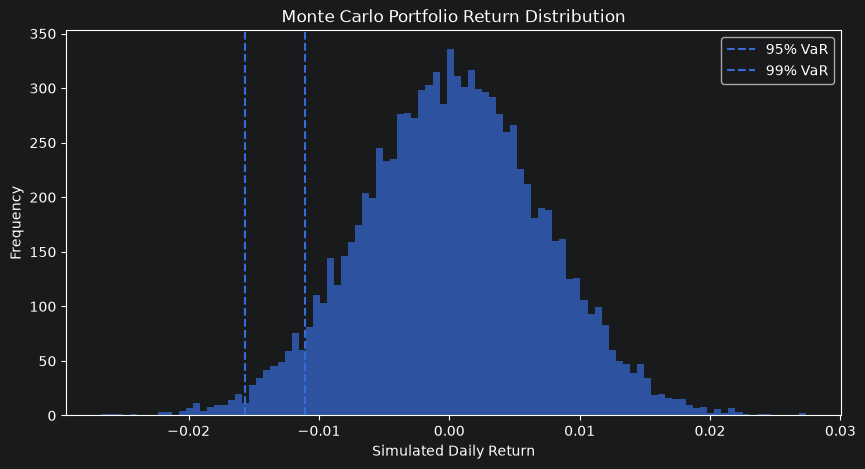

In [79]:
plt.figure(figsize=(10, 5))

plt.hist(simulated_returns, bins=100, alpha=0.7)

plt.axvline(
    monte_carlo_var_95,
    linestyle="--",
    label="95% VaR"
)

plt.axvline(
    monte_carlo_var_99,
    linestyle="--",
    label="99% VaR"
)

plt.title("Monte Carlo Portfolio Return Distribution")
plt.xlabel("Simulated Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [80]:
expected_shortfall_95 = simulated_returns[
    simulated_returns <= monte_carlo_var_95
].mean()

expected_shortfall_99 = simulated_returns[
    simulated_returns <= monte_carlo_var_99
].mean()

print(f"Expected Shortfall (95%): {expected_shortfall_95:.2%}")
print(f"Expected Shortfall (99%): {expected_shortfall_99:.2%}")

Expected Shortfall (95%): -1.40%
Expected Shortfall (99%): -1.82%


## Risk summary

The main risk measures are brought together to compare the portfolio under different risk frameworks.

In [81]:
risk_summary = pd.DataFrame({
    "Measure": [
        "Portfolio Volatility",
        "Historical VaR 95%",
        "Historical VaR 99%",
        "Parametric VaR 95%",
        "Parametric VaR 99%",
        "Monte Carlo VaR 95%",
        "Monte Carlo VaR 99%",
        "Expected Shortfall 95%",
        "Expected Shortfall 99%"
    ],
    "Value": [
        portfolio_volatility,
        historical_var_95,
        historical_var_99,
        parametric_var_95,
        parametric_var_99,
        monte_carlo_var_95,
        monte_carlo_var_99,
        expected_shortfall_95,
        expected_shortfall_99
    ]
})

risk_summary

,Measure,Value
0,Portfolio Volatility,0.109307
1,Historical VaR 95%,-0.009904
2,Historical VaR 99%,-0.023229
3,Parametric VaR 95%,-0.011003
4,Parametric VaR 99%,-0.015695
5,Monte Carlo VaR 95%,-0.011072
6,Monte Carlo VaR 99%,-0.015655
7,Expected Shortfall 95%,-0.013967
8,Expected Shortfall 99%,-0.018246


In [82]:
worst_scenario = historical_results.loc[
    historical_results["Portfolio Return"].idxmin()
]

worst_scenario

Scenario            COVID-19 Crash
Equity Return            -0.329971
Bond Return              -0.091309
Portfolio Return         -0.234506
Name: 0, dtype: object

In [83]:
scenario_comparison = historical_results[
    ["Scenario", "Equity Return", "Bond Return", "Portfolio Return"]
].copy()

scenario_comparison

,Scenario,Equity Return,Bond Return,Portfolio Return
0,COVID-19 Crash,-0.329971,-0.091309,-0.234506
1,COVID Crash + Partial Recovery Window,-0.157091,-0.036272,-0.108763
2,2022 Rate & Inflation Shock,-0.164753,-0.132069,-0.151679
3,2022 Stock-Bond Selloff,-0.133912,-0.157673,-0.143416
4,2025 Tariff Shock,-0.133847,-0.009319,-0.084036


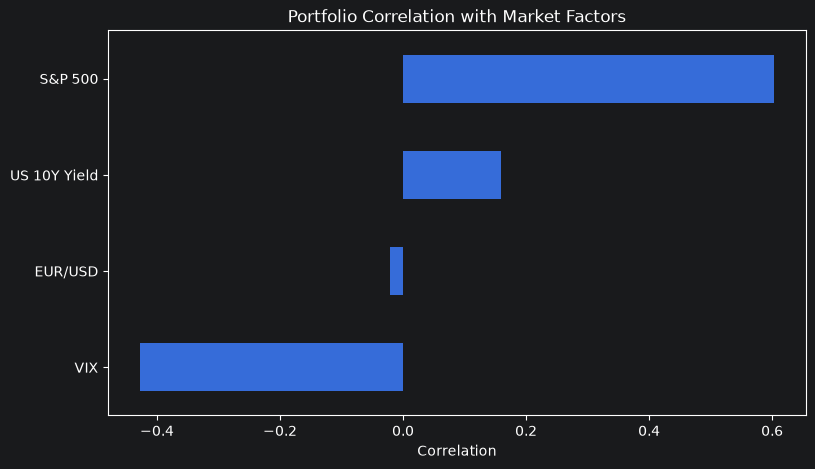

In [84]:
factor_correlation.sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    title="Portfolio Correlation with Market Factors"
)

plt.xlabel("Correlation")
plt.show()

## Final risk assessment

The analysis is summarized using the main portfolio risk and stress indicators.

In [85]:
final_results = {
    "Portfolio Volatility": portfolio_volatility,
    "Historical VaR 95%": historical_var_95,
    "Historical VaR 99%": historical_var_99,
    "Monte Carlo VaR 95%": monte_carlo_var_95,
    "Monte Carlo VaR 99%": monte_carlo_var_99,
    "Expected Shortfall 95%": expected_shortfall_95,
    "Expected Shortfall 99%": expected_shortfall_99,
    "Worst Historical Portfolio Return": worst_scenario["Portfolio Return"]
}

pd.Series(final_results)

Portfolio Volatility                 0.109307
Historical VaR 95%                  -0.009904
Historical VaR 99%                  -0.023229
Monte Carlo VaR 95%                 -0.011072
Monte Carlo VaR 99%                 -0.015655
Expected Shortfall 95%              -0.013967
Expected Shortfall 99%              -0.018246
Worst Historical Portfolio Return   -0.234506
dtype: float64

In [86]:
final_scenario_table = pd.concat(
    [
        historical_results[
            ["Scenario", "Portfolio Return"]
        ].assign(Type="Historical"),

        hypothetical_results[
            ["Scenario", "Portfolio Impact"]
        ].rename(
            columns={"Portfolio Impact": "Portfolio Return"}
        ).assign(Type="Hypothetical")
    ],
    ignore_index=True
)

final_scenario_table[
    ["Type", "Scenario", "Portfolio Return"]
]

,Type,Scenario,Portfolio Return
0,Historical,COVID-19 Crash,-0.234506
1,Historical,COVID Crash + Partial Recovery Window,-0.108763
2,Historical,2022 Rate & Inflation Shock,-0.151679
3,Historical,2022 Stock-Bond Selloff,-0.143416
4,Historical,2025 Tariff Shock,-0.084036
5,Hypothetical,Moderate Stress,-0.077254
6,Hypothetical,Severe Stress,-0.115882
7,Hypothetical,Extreme Stress,-0.154509


## One-Year Risk Perspective (Illustrative, Not a Regulatory SCR)

Solvency II — the regulatory framework governing European insurers and reinsurers, including Munich Re — requires capital sufficient to cover a 99.5% Value at Risk over a one-year horizon. This section connects the portfolio's daily risk estimate to a one-year view in three steps.

**A) Daily statistical estimate.** The code below computes the 99.5% daily historical VaR of the portfolio.

**B) Illustrative one-year scaling.** The daily figure is then scaled by √252 (square-root-of-time approximation) to obtain an illustrative one-year figure. This assumes daily returns are independent and identically distributed, which real markets do not fully satisfy (e.g. volatility clustering). **This provides an illustrative one-year risk perspective based on square-root-of-time scaling — it is not a Solvency II SCR calculation.**

Part C — why this is not the regulatory SCR — follows directly after the calculation below.


In [87]:
scr_confidence = 0.995

scr_var_daily = portfolio_returns.quantile(1 - scr_confidence)
scr_var_annual = scr_var_daily * np.sqrt(252)
scr_amount = portfolio_value * scr_var_annual

print(f"Solvency II-style VaR (99.5%, daily): {scr_var_daily:.2%}")
print(f"Solvency II-style capital buffer (99.5%, annualized): {scr_var_annual:.2%}")
print(f"Approximate capital buffer on a €{portfolio_value:,.0f} portfolio: €{abs(scr_amount):,.0f}")

Solvency II-style VaR (99.5%, daily): -2.74%
Solvency II-style capital buffer (99.5%, annualized): -43.45%
Approximate capital buffer on a €1,000,000 portfolio: €434,458


**Why this is not the regulatory SCR.** Solvency II's actual Solvency Capital Requirement is not a time-scaled VaR of a single portfolio return series. Under the Standard Formula, each risk type (equity, interest rate, spread, currency, and others) is shocked separately according to regulator-defined calibrations, and the resulting sub-module capital charges are combined using prescribed correlation matrices — or, alternatively, derived from a supervisor-approved internal model. The figure above is a simplified statistical illustration meant to connect this project's risk measures to a regulatory capital concept, not an attempt to reproduce the actual SCR methodology. It is the underlying daily figure, not the illustrative one-year figure, that is compared with the Extreme Value Theory results below.


## Extreme Value Theory: Tail Risk Beyond the Observed Data

All VaR estimates calculated so far rely on the 2020–2026 sample and
implicitly assume that future extreme losses will not exceed what has
already been observed. Extreme Value Theory (EVT) addresses this
limitation by modeling only the losses that exceed a high threshold, using
the Generalized Pareto Distribution (GPD) to extrapolate beyond the
observed data.

This Peaks-Over-Threshold (POT) approach is standard practice in actuarial
and reinsurance risk modeling, where the objective is precisely to
estimate the likelihood and severity of rare, catastrophic events that may
not yet be present in historical data.

In [88]:
from scipy.stats import genpareto

# Convert returns to losses (positive number = loss), and use the existing
# 95% VaR as the threshold that defines an "extreme" loss
losses = -portfolio_returns
threshold = var_95

exceedances = losses[losses > threshold] - threshold

shape, loc, scale = genpareto.fit(exceedances, floc=0)

n_total = len(portfolio_returns)
n_exceed = len(exceedances)

print(f"Number of exceedances above threshold: {n_exceed} out of {n_total}")
print(f"GPD shape parameter (xi): {shape:.4f}")
print(f"GPD scale parameter (sigma): {scale:.4f}")

def evt_var(confidence_level):
    q = 1 - confidence_level
    return threshold + (scale / shape) * (
        ((n_total / n_exceed) * q) ** (-shape) - 1
    )

evt_var_995 = evt_var(0.995)
evt_var_999 = evt_var(0.999)

print(f"\nEVT-based VaR (99.5%): {-evt_var_995:.2%}")
print(f"EVT-based VaR (99.9%): {-evt_var_999:.2%}")

Number of exceedances above threshold: 85 out of 1694
GPD shape parameter (xi): 0.3696
GPD scale parameter (sigma): 0.0048

EVT-based VaR (99.5%): -2.73%
EVT-based VaR (99.9%): -5.19%


The positive estimated shape parameter (ξ ≈ 0.37) indicates substantial tail heaviness in the fitted exceedance distribution, providing evidence of heavy-tailed risk consistent with the gap observed earlier between historical and parametric VaR. At the 99.5% level, the EVT-based daily estimate (-2.73%) is close to the daily 99.5% historical VaR computed above (-2.74%), on a comparable daily basis — the two are not the same calculation, but they broadly agree. At the 99.9% level — where fewer than two historical observations exist, making a direct empirical estimate statistically unreliable — EVT provides a model-based extrapolation of approximately -5.19%, nearly double the 99.5% estimate. This is the practical value of EVT in a reinsurance context: it allows reasoning about losses beyond anything in the historical record, rather than assuming the past sets the limit.


## Limitations & Assumptions

This analysis relies on several simplifying assumptions that should be
considered when interpreting the results:

- **Constant-weight allocation**: The 60/40 portfolio return is calculated using fixed
  weights applied each day, which is closer to a daily-rebalanced allocation than a
  true buy-and-hold portfolio whose weights would drift with market prices. A real
  institutional portfolio would follow an explicit rebalancing policy.
- **Normal distribution assumption**: The Parametric VaR and Monte Carlo
  simulation both assume normally distributed returns. Real financial
  returns typically exhibit fat tails, which these methods do not fully
  capture — as shown by the gap between Historical VaR (-2.32%) and
  Parametric/Monte Carlo VaR (-1.57%) at the 99% level.
- **Model risk / distributional assumptions**: The different VaR and ES estimates
  in this project depend on the assumed return distribution and tail behaviour
  (Normal, empirical, or Generalized Pareto). Alternative distributional or
  dependence assumptions could produce materially different results.
- **ETF proxies, not real portfolios**: EUNL.DE and EUN5.DE are simplified
  proxies for equity and bond exposure. A real institutional portfolio would
  include a much wider range of instruments, sectors, and currencies.
- **No transaction costs or liquidity constraints**: All calculations assume
  frictionless trading with no fees, slippage, or liquidity limitations.
- **Historical sample limitations**: The 99% VaR and Expected Shortfall
  estimates rely on only 17 tail observations out of 1,694, which introduces
  statistical uncertainty despite the Kupiec backtest result.
- **Single-day hypothetical shocks**: The hypothetical stress scenarios
  scale a single worst observed daily return and do not represent a
  cumulative multi-day event, unlike the historical scenarios.
- **Approximate bond duration**: The 5.5-year duration used in the interest
  rate shock analysis is an industry-typical estimate for a short-to-medium
  term euro corporate bond fund, not the fund's officially reported figure.
- **EVT threshold choice**: The Extreme Value Theory analysis uses the 95%
  VaR as the threshold defining "extreme" losses. A different threshold
  could yield somewhat different shape and scale parameter estimates,
  which is a known sensitivity in Peaks-Over-Threshold modeling.
- **Solvency II is illustrative only**: The one-year figure presented is a
  simplified statistical illustration, not a regulatory SCR calculation — the
  actual Solvency II Standard Formula combines separately shocked risk modules
  using prescribed correlation matrices, rather than scaling a single VaR
  estimate by time.


## Executive Summary

This project builds a quantitative risk analytics framework for a 60/40
equity-bond portfolio, combining traditional risk measures with stress
testing, factor analysis, extreme value theory, and formal statistical
validation.

The portfolio exhibits an annualized volatility of 10.9%, benefiting from a
1.1 percentage point diversification effect relative to its individually
weighted assets. Under normal market conditions, the 95% historical VaR
points to a potential daily loss of approximately 1.0% (€9,900 on a
€1,000,000 portfolio), rising to 2.3% (€23,200) at the 99% level.

A formal Kupiec Proportion of Failures test does not reject correct
unconditional coverage of the historical VaR model at either the 95% or
99% confidence level (p-values of 0.97 and 0.99 respectively), meaning
the observed frequency of VaR breaches is statistically consistent with
expectations. This test specifically evaluates VaR breach frequency; it
does not by itself validate Expected Shortfall or overall tail accuracy.

At the same time, the gap between historical VaR (-2.32%) and the
parametric/Monte Carlo VaR (-1.57%) at the 99% level suggests fatter tails
in the true return distribution than a Normal distribution assumption
would imply. This is supported by an Extreme Value Theory (EVT) analysis:
the fitted Generalized Pareto Distribution has a positive shape parameter
(ξ ≈ 0.37), providing evidence of heavy-tailed risk. The EVT-based 99.5%
daily VaR (-2.73%) is close to the daily 99.5% historical VaR underlying the
illustrative one-year risk perspective (-2.74%), while the
EVT-based 99.9% VaR (-5.19%) — a level with almost no direct historical
precedent in the sample — is a model-based extrapolation suggesting that
truly extreme losses could be nearly double that estimate.

Historical stress testing identifies the COVID-19 crash as the most severe
scenario, with a portfolio loss of -23.5%, driven primarily by the equity
component. During the 2022 stock-bond selloff, the bond position lost more
than the equity position (-15.8% vs -13.4%), showing that the
diversification benefit of fixed income can weaken when equity and bond
prices fall together, as happened during that period of rising rates. The
2025 tariff shock, a more recent event, produced a comparatively milder
-8.4% portfolio impact.

The portfolio shows a strong positive correlation with broad equity markets
(S&P 500: +0.60) and a strong negative correlation with market volatility
(VIX: -0.43), consistent with its equity-heavy composition. A duration-based
analysis further shows that a 100 basis point rise in interest rates would
reduce the bond position by approximately 5.5%, translating into a 2.2%
impact on the overall portfolio — a relevant consideration for
insurance-style asset-liability management.

Taken together, these results suggest that combining multiple,
complementary risk measures — including tail-risk methods drawn from
actuarial practice — gives a more reliable picture of portfolio risk than
relying on any single VaR estimate.
